In [1]:
import numpy as np #numerical computation
import pandas as pd #data wrangling
import matplotlib.pyplot as plt #plotting package
#Next line helps with rendering plots
%matplotlib inline
import matplotlib as mpl #add'l plotting functionality
mpl.rcParams['figure.dpi'] = 400 #high res figures
import graphviz #to visualize decision trees

In [2]:
df = pd.read_csv('df_cleaned.csv')

In [5]:
features_response = df.columns.tolist()


In [6]:
items_to_remove = ['ID', 'SEX', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6',
                   'EDUCATION_CAT', 'graduate school', 'high school', 'none',
                   'others', 'university']

In [7]:
features_response = [item for item in features_response if item not in items_to_remove]
features_response

['LIMIT_BAL',
 'EDUCATION',
 'MARRIAGE',
 'AGE',
 'PAY_1',
 'BILL_AMT1',
 'BILL_AMT2',
 'BILL_AMT3',
 'BILL_AMT4',
 'BILL_AMT5',
 'BILL_AMT6',
 'PAY_AMT1',
 'PAY_AMT2',
 'PAY_AMT3',
 'PAY_AMT4',
 'PAY_AMT5',
 'PAY_AMT6',
 'default payment next month']

In [10]:
from sklearn.model_selection import train_test_split
from sklearn import tree
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier

In [9]:
X_train, X_test, y_train, y_test = \
train_test_split(df[features_response[:-1]].values,
                 df['default payment next month'].values,
                 test_size=0.2, random_state=24)

In [11]:
rf_params = {'max_depth':[3, 6, 9, 12],
             'n_estimators':[10, 50, 100, 200]}

In [17]:
rf = RandomForestClassifier\
(n_estimators=10, criterion='gini', max_depth=3,
min_samples_split=2, min_samples_leaf=1, min_weight_fraction_leaf=0.0,
max_features='sqrt', max_leaf_nodes=None, 
bootstrap=True, oob_score=False, n_jobs=None,
random_state=4, verbose=0, warm_start=False, class_weight=None)

In [18]:
cv_rf = GridSearchCV(rf, param_grid=rf_params, scoring='roc_auc',
                     n_jobs=-1, refit=True, cv=4, verbose=2,
                     error_score=np.nan, return_train_score=True)

In [19]:
cv_rf.fit(X_train, y_train)

Fitting 4 folds for each of 16 candidates, totalling 64 fits


GridSearchCV(cv=4,
             estimator=RandomForestClassifier(max_depth=3, n_estimators=10,
                                              random_state=4),
             n_jobs=-1,
             param_grid={'max_depth': [3, 6, 9, 12],
                         'n_estimators': [10, 50, 100, 200]},
             return_train_score=True, scoring='roc_auc', verbose=2)

In [20]:
cv_rf_results_df = pd.DataFrame(cv_rf.cv_results_)
cv_rf_results_df

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_max_depth,param_n_estimators,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,mean_test_score,std_test_score,rank_test_score,split0_train_score,split1_train_score,split2_train_score,split3_train_score,mean_train_score,std_train_score
0,0.135171,0.005529,0.005541,0.004677,3,10,"{'max_depth': 3, 'n_estimators': 10}",0.739183,0.746599,0.772127,0.771322,0.757308,0.014656,15,0.767973,0.767158,0.760550,0.763683,0.764841,0.002955
1,0.539513,0.016422,0.010503,0.000501,3,50,"{'max_depth': 3, 'n_estimators': 50}",0.748009,0.755878,0.779465,0.771250,0.763651,0.012379,12,0.775241,0.774025,0.765732,0.766947,0.770486,0.004191
2,1.029707,0.017841,0.015806,0.001983,3,100,"{'max_depth': 3, 'n_estimators': 100}",0.747221,0.753924,0.779195,0.770937,0.762819,0.012811,13,0.774340,0.773598,0.766103,0.766914,0.770238,0.003750
3,2.046443,0.045363,0.030095,0.001128,3,200,"{'max_depth': 3, 'n_estimators': 200}",0.747454,0.753057,0.777644,0.771729,0.762471,0.012550,14,0.774453,0.773534,0.766139,0.767404,0.770382,0.003653
4,0.183936,0.008381,0.003435,0.000073,6,10,"{'max_depth': 6, 'n_estimators': 10}",0.752905,0.758904,0.780036,0.774017,0.766466,0.010980,11,0.795911,0.796476,0.793695,0.796446,0.795632,0.001141
5,0.936090,0.053045,0.012665,0.001577,6,50,"{'max_depth': 6, 'n_estimators': 50}",0.760087,0.765251,0.788567,0.778669,0.773143,0.011194,8,0.807082,0.805109,0.799176,0.801229,0.803149,0.003114
6,1.851553,0.042859,0.024686,0.002020,6,100,"{'max_depth': 6, 'n_estimators': 100}",0.760964,0.765515,0.788793,0.778936,0.773552,0.011004,7,0.808196,0.806130,0.800846,0.803123,0.804574,0.002808
7,3.681746,0.089047,0.050968,0.005439,6,200,"{'max_depth': 6, 'n_estimators': 200}",0.761481,0.765319,0.787854,0.779745,0.773600,0.010682,6,0.808277,0.806853,0.800682,0.804006,0.804955,0.002907
8,0.258614,0.002897,0.006897,0.001144,9,10,"{'max_depth': 9, 'n_estimators': 10}",0.757853,0.755539,0.781513,0.774303,0.767302,0.010939,10,0.854161,0.856208,0.850357,0.852009,0.853184,0.002206
9,1.317961,0.022457,0.017124,0.001494,9,50,"{'max_depth': 9, 'n_estimators': 50}",0.763971,0.764423,0.786693,0.780310,0.773849,0.009914,4,0.867239,0.871379,0.868216,0.867384,0.868554,0.001673


[CV] END .......................max_depth=3, n_estimators=50; total time=   0.0s
[CV] END .......................max_depth=3, n_estimators=50; total time=   0.6s
[CV] END ......................max_depth=3, n_estimators=200; total time=   2.0s
[CV] END ......................max_depth=6, n_estimators=200; total time=   3.7s
[CV] END ......................max_depth=6, n_estimators=200; total time=   3.7s
[CV] END .......................max_depth=3, n_estimators=50; total time=   0.0s
[CV] END ......................max_depth=9, n_estimators=100; total time=   0.0s
[CV] END ......................max_depth=9, n_estimators=200; total time=   0.0s
[CV] END ......................max_depth=12, n_estimators=10; total time=   0.0s
[CV] END ......................max_depth=12, n_estimators=10; total time=   0.0s
[CV] END ......................max_depth=12, n_estimators=50; total time=   0.0s
[CV] END ......................max_depth=12, n_estimators=50; total time=   0.0s
[CV] END ...................

In [26]:
cv_rf.best_params_

{'max_depth': 9, 'n_estimators': 200}

In [29]:
cv_rf.best_score_

np.float64(0.7762347109623667)

In [23]:
xx_rf, yy_rf = np.meshgrid(range(5), range(5))

In [24]:
cm_rf = plt.cm.jet

Text(0, 0.5, 'Maximum depth')

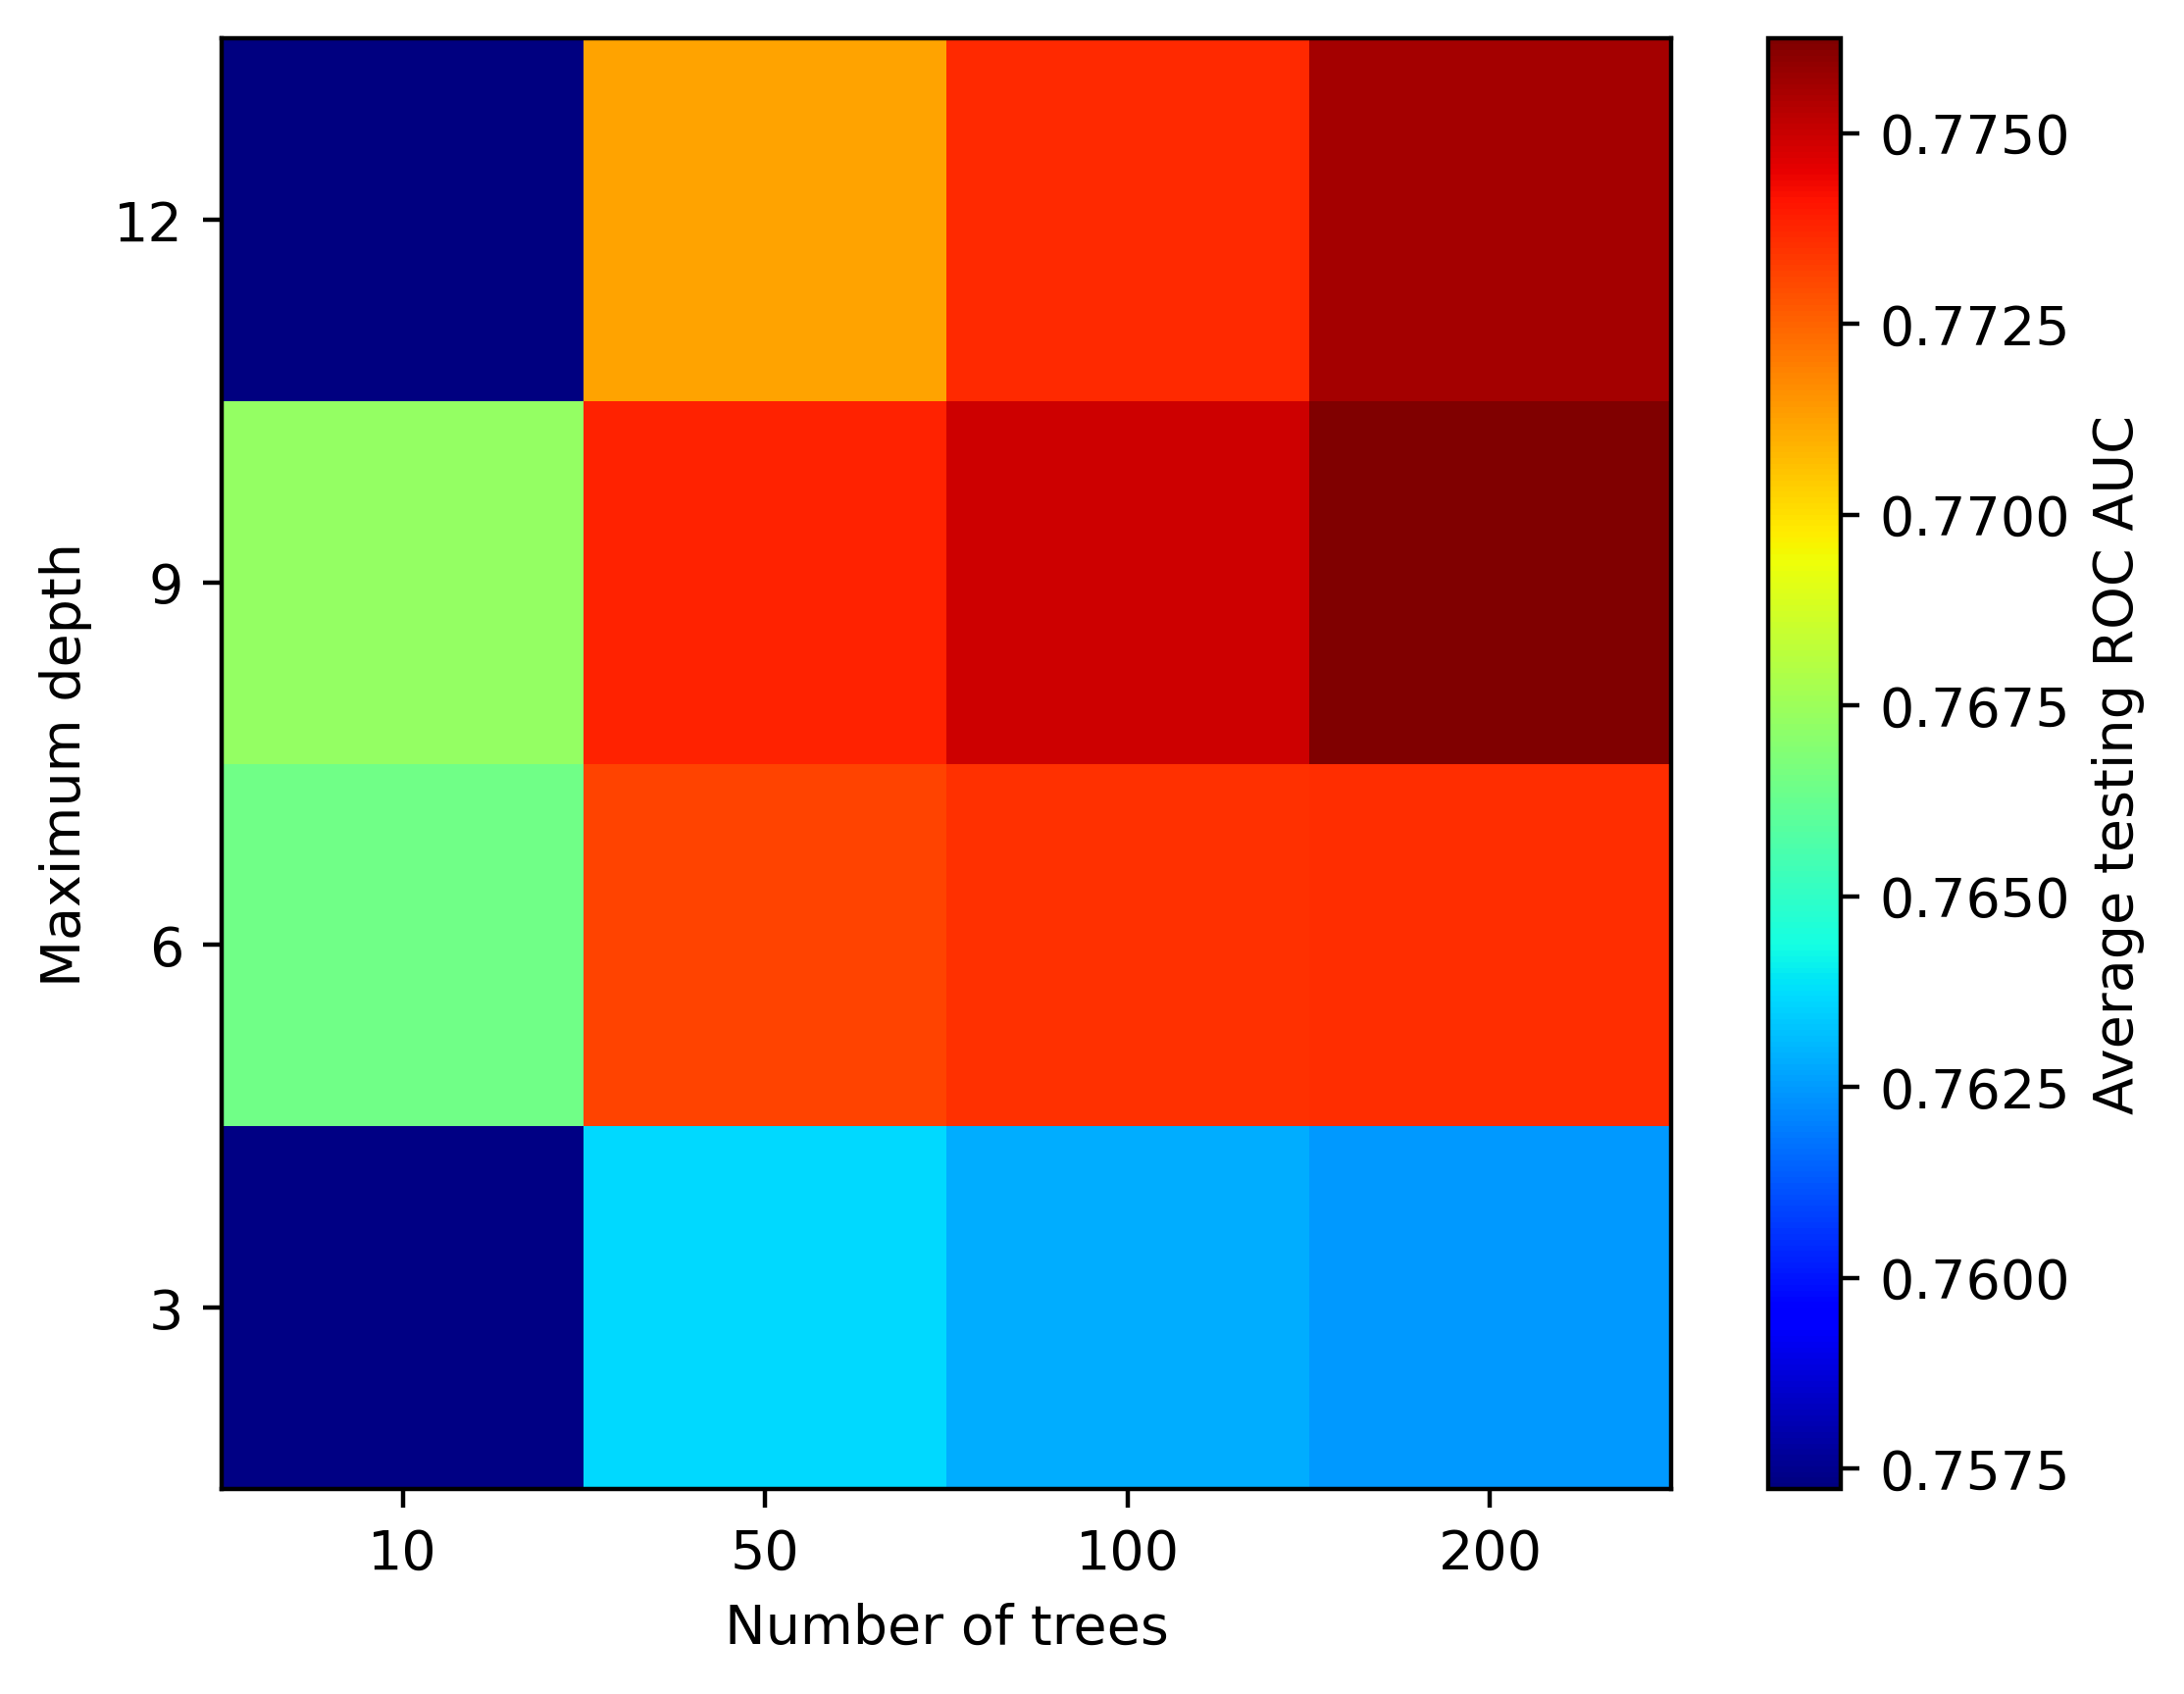

In [25]:
ax_rf = plt.axes()
pcolor_graph = ax_rf.pcolormesh(
    xx_rf, yy_rf,
    cv_rf_results_df['mean_test_score'].values.reshape((4,4)),
    cmap=cm_rf)
plt.colorbar(pcolor_graph, label='Average testing ROC AUC')
ax_rf.set_aspect('equal')
ax_rf.set_xticks([0.5, 1.5, 2.5, 3.5])
ax_rf.set_yticks([0.5, 1.5, 2.5, 3.5])
ax_rf.set_xticklabels(
    [str(tick_label) for tick_label in rf_params['n_estimators']])
ax_rf.set_yticklabels(
    [str(tick_label) for tick_label in rf_params['max_depth']])
ax_rf.set_xlabel('Number of trees')
ax_rf.set_ylabel('Maximum depth')

In [27]:
feat_imp_df_act = pd.DataFrame({
    'Feature name':features_response[:-1],
    'Importance':cv_rf.best_estimator_.feature_importances_
})

In [28]:
feat_imp_df_act.sort_values('Importance', ascending=False)

,Feature name,Importance
4,PAY_1,0.440503
0,LIMIT_BAL,0.059277
11,PAY_AMT1,0.059265
12,PAY_AMT2,0.045091
13,PAY_AMT3,0.043033
5,BILL_AMT1,0.042240
6,BILL_AMT2,0.041417
7,BILL_AMT3,0.037040
8,BILL_AMT4,0.034097
14,PAY_AMT4,0.033706
